In [1]:
import pandas as pd
import numpy as np

# PHASE 1: DATA CLEANING (MANDATORY)


In [2]:
df = pd.read_csv("data/nigeria_medical_insurance.csv")
df.head()

,Age,Gender,BMI,Children,Smoker?,State,Hospital_Bill
0,47yrs,Male,45.3kg/m2,none,Yes,Rivers,₦12854792.7
1,33.0,Female,"22.7,","0,",N,Kaduna,₦32976705.91
2,"64,",F,39.0,none,yes,Lagos,"24,127,691"
3,age_36,M,28.9,"3,",?,Oyo,"10,122,887"
4,"49,",Female,"42.7,",2.0,Yes,KANO,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1472 entries, 0 to 1471
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Age            1472 non-null   str  
 1    Gender        1304 non-null   str  
 2   BMI            1472 non-null   str  
 3   Children       1233 non-null   str  
 4   Smoker?        1472 non-null   str  
 5    State         1472 non-null   str  
 6   Hospital_Bill  1250 non-null   str  
dtypes: str(7)
memory usage: 129.3 KB


In [4]:
df.describe()

,Age,Gender,BMI,Children,Smoker?,State,Hospital_Bill
count,1472,1304,1472,1233,1472,1472,1250
unique,235,7,576,20,9,11,1139
top,?,Male,??,three,Yes,Rivers,₦32976705.91
freq,260,213,255,257,185,154,2


In [5]:
df.dtypes

Age              str
 Gender          str
BMI              str
Children         str
Smoker?          str
 State           str
Hospital_Bill    str
dtype: object

In [6]:
df.columns = (
    df.columns
    .str.strip()
    .str.replace("?", "", regex=False)
    .str.title()
    .str.replace("_", " ")
)
df.columns


Index(['Age', 'Gender', 'Bmi', 'Children', 'Smoker', 'State', 'Hospital Bill'], dtype='str')

In [7]:
df.isnull().sum()

Age                0
Gender           168
Bmi                0
Children         239
Smoker             0
State              0
Hospital Bill    222
dtype: int64

In [8]:
df = df.drop_duplicates()
df

,Age,Gender,Bmi,Children,Smoker,State,Hospital Bill
0,47yrs,Male,45.3kg/m2,none,Yes,Rivers,₦12854792.7
1,33.0,Female,"22.7,","0,",N,Kaduna,₦32976705.91
2,"64,",F,39.0,none,yes,Lagos,"24,127,691"
3,age_36,M,28.9,"3,",?,Oyo,"10,122,887"
4,"49,",Female,"42.7,",2.0,Yes,KANO,NaN
...,...,...,...,...,...,...,...
1465,age_37,NaN,??,2,yes,Kaduna,₦10029646.95
1466,?,unknown,"33.9,",none,smoker,KANO,₦ 70333891.8
1467,60.0,unknown,"38.1,","0,",yes,Kano,"18,973,055"
1468,age_21,M,"35.5,",0.0,Yes,KANO,2298704.55 NGN


In [9]:
# Age
df["Age"] = (
    df["Age"]
    .astype(str)
    .str.extract(r"(\d+\.?\d*)")[0]   # Extract numbers only
)
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
df['Age']

0       47.0
1       33.0
2       64.0
3       36.0
4       49.0
        ... 
1465    37.0
1466     NaN
1467    60.0
1468    21.0
1469    58.0
Name: Age, Length: 1338, dtype: float64

In [10]:
# BMI
df["Bmi"] = (
    df["Bmi"]
    .astype(str)
    .str.replace("kg/m2", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.extract(r"(\d+\.?\d*)")[0]
)
df["Bmi"] = pd.to_numeric(df["Bmi"], errors="coerce")
df["Bmi"]

0       45.3
1       22.7
2       39.0
3       28.9
4       42.7
        ... 
1465     NaN
1466    33.9
1467    38.1
1468    35.5
1469    34.4
Name: Bmi, Length: 1338, dtype: float64

In [11]:
# Children
df["Children"] = (
    df["Children"]
    .astype(str)
    .str.lower()
    .replace({"none": "0"})
    .str.replace(",", "", regex=False)
    .str.extract(r"(\d+\.?\d*)")[0]
)
df["Children"] = pd.to_numeric(df["Children"], errors="coerce")
df["Children"]

0       0.0
1       0.0
2       0.0
3       3.0
4       2.0
       ... 
1465    2.0
1466    0.0
1467    0.0
1468    0.0
1469    0.0
Name: Children, Length: 1338, dtype: float64

In [12]:
# Hospital Bill
df["Hospital Bill"] = (
    df["Hospital Bill"]
    .astype(str)
    .str.replace("₦", "", regex=False)
    .str.replace("NGN", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)
df["Hospital Bill"] = pd.to_numeric(df["Hospital Bill"], errors="coerce")
df["Hospital Bill"]

0       12854792.70
1       32976705.91
2       24127691.00
3       10122887.00
4               NaN
           ...     
1465    10029646.95
1466    70333891.80
1467    18973055.00
1468     2298704.55
1469    17615901.15
Name: Hospital Bill, Length: 1338, dtype: float64

In [13]:
df.dtypes

Age              float64
Gender               str
Bmi              float64
Children         float64
Smoker               str
State                str
Hospital Bill    float64
dtype: object

In [14]:
df["Gender"] = (
    df["Gender"]
    .str.strip()
    .str.lower()
    .replace({
        "male":"Male",
        "m":"Male",
        "female":"Female",
        "f":"Female",
        "fem": "Female"
    })
)
df["Gender"]

0          Male
1        Female
2        Female
3          Male
4        Female
         ...   
1465        NaN
1466    unknown
1467    unknown
1468       Male
1469    unknown
Name: Gender, Length: 1338, dtype: str

In [15]:
df['Gender'].unique()

<ArrowStringArray>
['Male', 'Female', 'unknown', nan]
Length: 4, dtype: str

In [16]:
df["Gender"] = df["Gender"].replace("unknown", np.nan)
df["Gender"]

0         Male
1       Female
2       Female
3         Male
4       Female
         ...  
1465       NaN
1466       NaN
1467       NaN
1468      Male
1469       NaN
Name: Gender, Length: 1338, dtype: str

In [17]:
# Gender: Fill missing values with the mode (most frequent value)
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])
df["Gender"]

0         Male
1       Female
2       Female
3         Male
4       Female
         ...  
1465    Female
1466    Female
1467    Female
1468      Male
1469    Female
Name: Gender, Length: 1338, dtype: str

In [18]:
# Children: Fill missing values with 0
df["Children"] = df["Children"].fillna(0)
df["Children"]

0       0.0
1       0.0
2       0.0
3       3.0
4       2.0
       ... 
1465    2.0
1466    0.0
1467    0.0
1468    0.0
1469    0.0
Name: Children, Length: 1338, dtype: float64

In [19]:
# Hospital Bill: Remove rows where the target is missing
df = df.dropna(subset=["Hospital Bill"])
df

,Age,Gender,Bmi,Children,Smoker,State,Hospital Bill
0,47.0,Male,45.3,0.0,Yes,Rivers,12854792.70
1,33.0,Female,22.7,0.0,N,Kaduna,32976705.91
2,64.0,Female,39.0,0.0,yes,Lagos,24127691.00
3,36.0,Male,28.9,3.0,?,Oyo,10122887.00
5,34.0,Male,33.2,1.0,Yes,Abuja,8392268.25
...,...,...,...,...,...,...,...
1465,37.0,Female,NaN,2.0,yes,Kaduna,10029646.95
1466,NaN,Female,33.9,0.0,smoker,KANO,70333891.80
1467,60.0,Female,38.1,0.0,yes,Kano,18973055.00
1468,21.0,Male,35.5,0.0,Yes,KANO,2298704.55


In [20]:
df["Bmi"] = df["Bmi"].fillna(df["Bmi"].median())
df["Bmi"]

0       45.3
1       22.7
2       39.0
3       28.9
5       33.2
        ... 
1465    30.5
1466    33.9
1467    38.1
1468    35.5
1469    34.4
Name: Bmi, Length: 1139, dtype: float64

In [21]:
df['Smoker'].unique()

<ArrowStringArray>
['Yes', 'N', 'yes', '?', 'No', 'smoker', 'Y', 'no', 'non-smoker']
Length: 9, dtype: str

In [22]:
# Clean the Smoker? column
df["Smoker"] = (
    df["Smoker"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        "yes": "Yes",
        "y": "Yes",
        "smoker": "Yes",
        "no": "No",
        "n": "No",
        "non-smoker": "No",
        "?": np.nan
    })
)
df["Smoker"]

0       Yes
1        No
2       Yes
3       NaN
5       Yes
       ... 
1465    Yes
1466    Yes
1467    Yes
1468    Yes
1469    Yes
Name: Smoker, Length: 1139, dtype: str

In [23]:
df["Smoker"] = df["Smoker"].fillna(df["Smoker"].mode()[0])
df["Smoker"]

0       Yes
1        No
2       Yes
3       Yes
5       Yes
       ... 
1465    Yes
1466    Yes
1467    Yes
1468    Yes
1469    Yes
Name: Smoker, Length: 1139, dtype: str

In [24]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Age"]

0       47.0
1       33.0
2       64.0
3       36.0
5       34.0
        ... 
1465    37.0
1466    39.0
1467    60.0
1468    21.0
1469    58.0
Name: Age, Length: 1139, dtype: float64

In [25]:
df.isnull().sum()

Age              0
Gender           0
Bmi              0
Children         0
Smoker           0
State            0
Hospital Bill    0
dtype: int64

In [26]:
df

,Age,Gender,Bmi,Children,Smoker,State,Hospital Bill
0,47.0,Male,45.3,0.0,Yes,Rivers,12854792.70
1,33.0,Female,22.7,0.0,No,Kaduna,32976705.91
2,64.0,Female,39.0,0.0,Yes,Lagos,24127691.00
3,36.0,Male,28.9,3.0,Yes,Oyo,10122887.00
5,34.0,Male,33.2,1.0,Yes,Abuja,8392268.25
...,...,...,...,...,...,...,...
1465,37.0,Female,30.5,2.0,Yes,Kaduna,10029646.95
1466,39.0,Female,33.9,0.0,Yes,KANO,70333891.80
1467,60.0,Female,38.1,0.0,Yes,Kano,18973055.00
1468,21.0,Male,35.5,0.0,Yes,KANO,2298704.55


In [27]:
print(df["State"].value_counts())

State
Rivers     116
Enugu      115
?          113
Lagos      109
Abuja      104
Kano       104
abuja      104
KANO       103
 Lagos      96
Kaduna      88
Oyo         87
Name: count, dtype: int64


In [28]:
# Standardize State column
df["State"] = (
    df["State"]
    .astype(str)
    .str.strip()      # Remove leading/trailing spaces
    .str.title()      # Convert to Title Case
    .replace("?", np.nan)  # Replace ? with NaN
)
df["State"]

0       Rivers
1       Kaduna
2        Lagos
3          Oyo
5        Abuja
         ...  
1465    Kaduna
1466      Kano
1467      Kano
1468      Kano
1469     Lagos
Name: State, Length: 1139, dtype: str

In [29]:
# Fill missing states with the mode (most common state)
df["State"] = df["State"].fillna(df["State"].mode()[0])
df["State"]

0       Rivers
1       Kaduna
2        Lagos
3          Oyo
5        Abuja
         ...  
1465    Kaduna
1466      Kano
1467      Kano
1468      Kano
1469     Lagos
Name: State, Length: 1139, dtype: str

In [30]:
print(df["State"].value_counts())

State
Abuja     321
Kano      207
Lagos     205
Rivers    116
Enugu     115
Kaduna     88
Oyo        87
Name: count, dtype: int64


In [31]:
df

,Age,Gender,Bmi,Children,Smoker,State,Hospital Bill
0,47.0,Male,45.3,0.0,Yes,Rivers,12854792.70
1,33.0,Female,22.7,0.0,No,Kaduna,32976705.91
2,64.0,Female,39.0,0.0,Yes,Lagos,24127691.00
3,36.0,Male,28.9,3.0,Yes,Oyo,10122887.00
5,34.0,Male,33.2,1.0,Yes,Abuja,8392268.25
...,...,...,...,...,...,...,...
1465,37.0,Female,30.5,2.0,Yes,Kaduna,10029646.95
1466,39.0,Female,33.9,0.0,Yes,Kano,70333891.80
1467,60.0,Female,38.1,0.0,Yes,Kano,18973055.00
1468,21.0,Male,35.5,0.0,Yes,Kano,2298704.55


In [32]:
df.duplicated().sum()

np.int64(0)

In [33]:
df["Hospital Bill"].describe()

count    1.139000e+03
mean     1.966716e+07
std      1.819982e+07
min      1.697260e+06
25%      7.003686e+06
50%      1.377326e+07
75%      2.419055e+07
max      9.565564e+07
Name: Hospital Bill, dtype: float64

In [54]:
df = df[df["Hospital Bill"] > 0]
df

,Age,Gender,Bmi,Children,Smoker,State,Hospital Bill
0,47.0,Male,45.3,0.0,Yes,Rivers,12854792.70
1,33.0,Female,22.7,0.0,No,Kaduna,32976705.91
2,64.0,Female,39.0,0.0,Yes,Lagos,24127691.00
3,36.0,Male,28.9,3.0,Yes,Oyo,10122887.00
5,34.0,Male,33.2,1.0,Yes,Abuja,8392268.25
...,...,...,...,...,...,...,...
1465,37.0,Female,30.5,2.0,Yes,Kaduna,10029646.95
1466,39.0,Female,33.9,0.0,Yes,Kano,70333891.80
1467,60.0,Female,38.1,0.0,Yes,Kano,18973055.00
1468,21.0,Male,35.5,0.0,Yes,Kano,2298704.55


In [55]:
# exclude outliers in dataframe

Q1 = df['Bmi'].quantile(0.25)
Q3 = df['Bmi'].quantile(0.75)

IQR = Q3 - Q1

bmi_lower_bound = Q1 - 1.5 * IQR
bmi_upper_bound = Q3 + 1.5 * IQR

outliers = (df['Bmi'] < bmi_lower_bound) | (df['Bmi'] > bmi_upper_bound)

print("BMI outliers:", outliers.sum())

BMI outliers: 139


In [56]:
# exclude outliers in dataframe

Q1 = df['Hospital Bill'].quantile(0.25)
Q3 = df['Hospital Bill'].quantile(0.75)

IQR = Q3 - Q1

bill_lower_bound = Q1 - 1.5 * IQR
bill_upper_bound = Q3 + 1.5 * IQR

outliers = (df['Hospital Bill'] < bill_lower_bound) | (df['Hospital Bill'] > bill_upper_bound)

print("Hospital Bill outliers:", outliers.sum())

Hospital Bill outliers: 127


In [57]:
#exclude an outliers in dataframe

Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)

IQR = Q3 - Q1

age_lower_bound = Q1 - 1.5 * IQR
age_upper_bound = Q3 + 1.5 * IQR

outliers = (df['Age'] < age_lower_bound) | (df['Age'] > age_upper_bound)

print("Age outliers:", outliers.sum())

Age outliers: 0


In [58]:
# exclude outliers in dataframe

Q1 = df['Children'].quantile(0.25)
Q3 = df['Children'].quantile(0.75)

IQR = Q3 - Q1

children_lower_bound = Q1 - 1.5 * IQR
children_upper_bound = Q3 + 1.5 * IQR

outliers = (df['Children'] < children_lower_bound) | (df['Children'] > children_upper_bound)

print("Children outliers:", outliers.sum())

Children outliers: 93


In [61]:
df = df[
    (df['Age'] > age_lower_bound) &
    (df['Age'] < age_upper_bound) &
    (df['Bmi'] > bmi_lower_bound) &
    (df['Bmi'] < bmi_upper_bound) &
    (df['Children'] > children_lower_bound) &
    (df['Children'] < children_upper_bound) &
    (df['Hospital Bill'] > bill_lower_bound) &
    (df['Hospital Bill'] < bill_upper_bound)
]
df.shape

(817, 7)

In [62]:
df.info()

<class 'pandas.DataFrame'>
Index: 817 entries, 1 to 1469
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Age            817 non-null    float64
 1   Gender         817 non-null    str    
 2   Bmi            817 non-null    float64
 3   Children       817 non-null    float64
 4   Smoker         817 non-null    str    
 5   State          817 non-null    str    
 6   Hospital Bill  817 non-null    float64
dtypes: float64(4), str(3)
memory usage: 61.5 KB


In [78]:
df['Age'].min()

np.float64(18.0)

In [79]:
df.to_csv("data/clean_nigeria_medical_insurance.csv",index=False)

# Data Cleaning Report

The dataset was cleaned to improve data quality and prepare it for exploratory data analysis and machine learning.

### 1. Age

* Extracted numeric values from entries such as `47yrs`, `age_36`, and `64,`.
* Converted the column to a numeric (`float`) data type.
* Invalid entries such as `?` were converted to missing values (`NaN`).

### 2. Gender

* Standardized gender values by converting abbreviations:

  * `M` → `Male`
  * `F` → `Female`
* Replaced `unknown` and missing values with the most frequent gender (mode).

### 3. BMI

* Removed unnecessary text such as `kg/m2` and commas.
* Converted the column to a numeric (`float`) data type.
* Invalid values were converted to `NaN`.

### 4. Children

* Replaced `none` with `0`.
* Removed commas and converted the column to a numeric (`float`) data type.
* Missing values were filled with `0`.

### 5. Smoker Status

* Standardized all smoking status values into two categories:

  * `Yes`: (`Yes`, `yes`, `Y`, `smoker`)
  * `No`: (`No`, `no`, `N`, `non-smoker`)
* Replaced `?` with a missing value and filled it using the most frequent category.

### 6. State

* Removed leading and trailing spaces.
* Standardized capitalization using title case (e.g., `KANO`, `kano`, ` Kano` → `Kano`).
* Replaced `?` with a missing value and filled it with the most frequent state.

### 7. Hospital Bill

* Removed currency symbols (`₦`), currency codes (`NGN`), commas, and extra spaces.
* Converted the column to a numeric (`float`) data type.
* Rows with missing hospital bill values were removed because the hospital bill is the target variable for prediction.

### 8. General Data Quality Checks

* Checked for missing values across all columns.
* Verified data types to ensure numeric columns were stored as numeric variables.
* Checked for duplicate records and removed duplicates where necessary.
* Verified that the target variable contained valid positive values.

### Summary

After cleaning, the dataset contained standardized categorical variables, properly formatted numeric variables, consistent state names, and a clean target variable suitable for exploratory data analysis and machine learning model development.


# PHASE 2: EXPLORATORY DATA ANALYSIS (EDA)


In [80]:
import plotly.express as px

# 1. Univariate Analysis


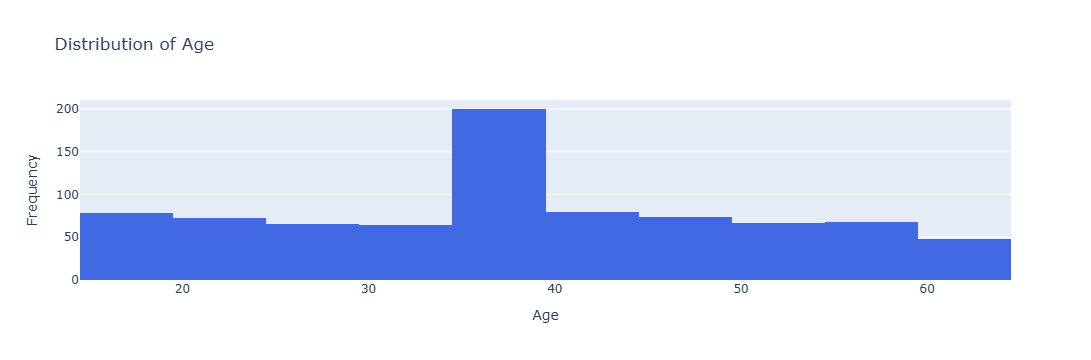

In [81]:
fig1 = px.histogram(
    df,
    x="Age",
    nbins=20,
    title="Distribution of Age",
    color_discrete_sequence=["royalblue"]
)

fig1.update_layout(
    xaxis_title="Age",
    yaxis_title="Frequency"
)

fig1.show()

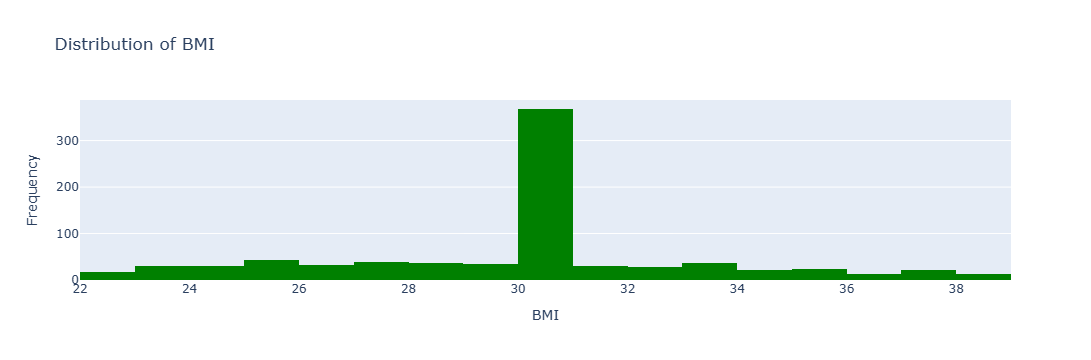

In [82]:
fig2 = px.histogram(
    df,
    x="Bmi",
    nbins=20,
    title="Distribution of BMI",
    color_discrete_sequence=["green"]
)

fig2.update_layout(
    xaxis_title="BMI",
    yaxis_title="Frequency"
)

fig2.show()

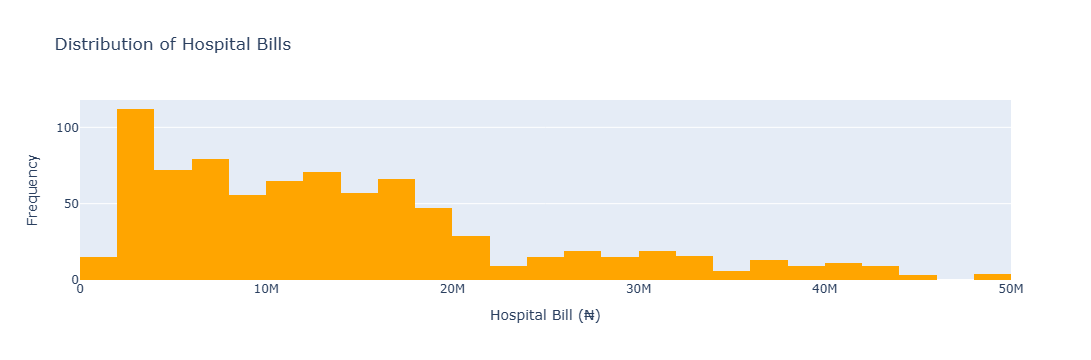

In [83]:
fig3 = px.histogram(
    df,
    x="Hospital Bill",
    nbins=30,
    title="Distribution of Hospital Bills",
    color_discrete_sequence=["orange"]
)

fig3.update_layout(
    xaxis_title="Hospital Bill (₦)",
    yaxis_title="Frequency"
)

fig3.show()

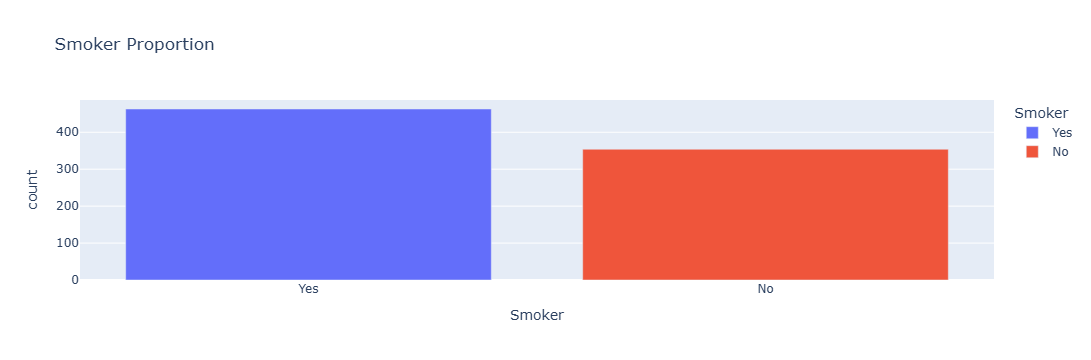

In [84]:
fig4 = px.bar(
    df["Smoker"].value_counts().reset_index(),
    x="Smoker",
    y="count",
    title="Smoker Proportion",
    color="Smoker"
)

fig4.show()

# 2. Bivariate Analysis


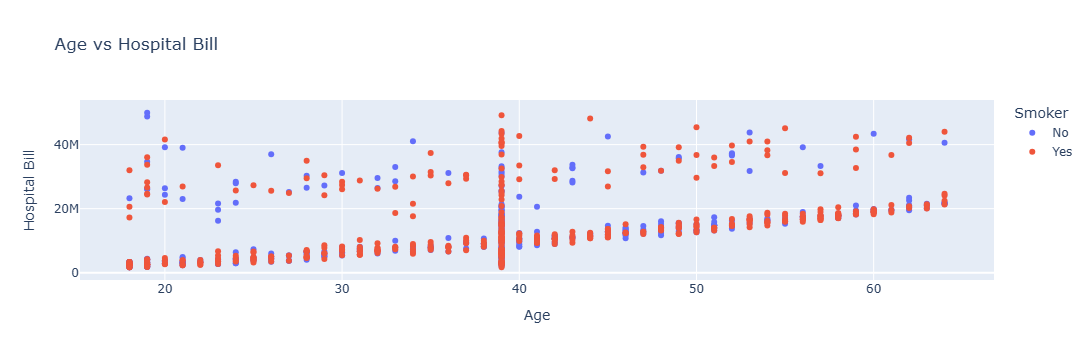

In [85]:
fig5 = px.scatter(
    df,
    x="Age",
    y="Hospital Bill",
    color="Smoker",
    title="Age vs Hospital Bill",
    hover_data=["Gender", "State"]
)

fig5.show()

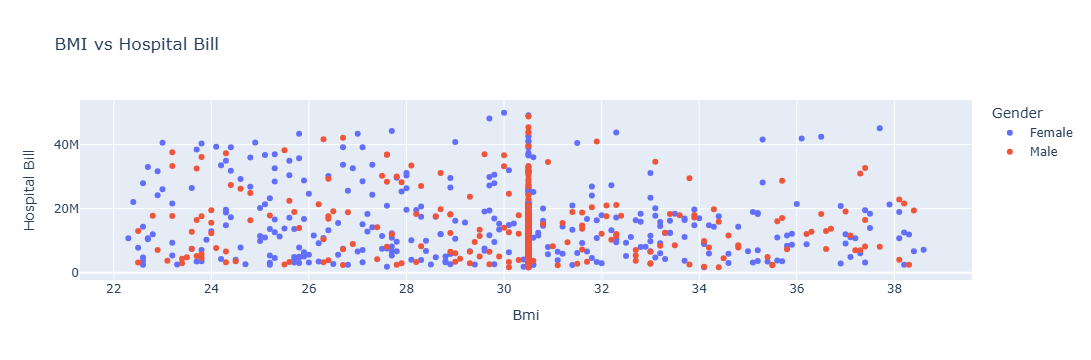

In [86]:
fig6 = px.scatter(
    df,
    x="Bmi",
    y="Hospital Bill",
    color="Gender",
    title="BMI vs Hospital Bill"
)

fig6.show()

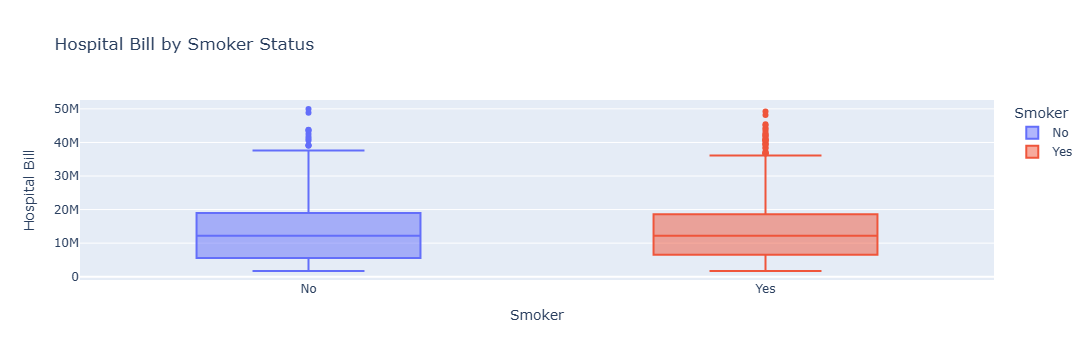

In [87]:
fig7 = px.box(
    df,
    x="Smoker",
    y="Hospital Bill",
    color="Smoker",
    title="Hospital Bill by Smoker Status"
)

fig7.show()

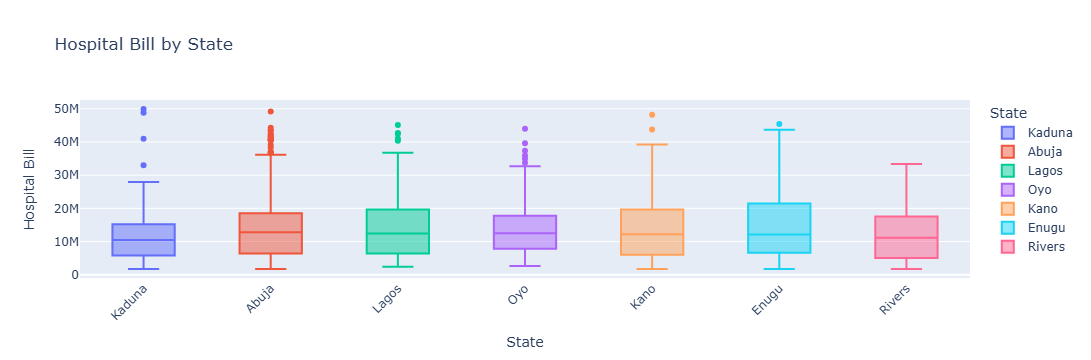

In [88]:
fig8 = px.box(
    df,
    x="State",
    y="Hospital Bill",
    color="State",
    title="Hospital Bill by State"
)

fig8.update_layout(xaxis_tickangle=-45)

fig8.show()

# 3. Multivariate Analysis


C:\Users\user\AppData\Local\Temp\ipykernel_6220\3774952190.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in corr_df.select_dtypes(include="object"):


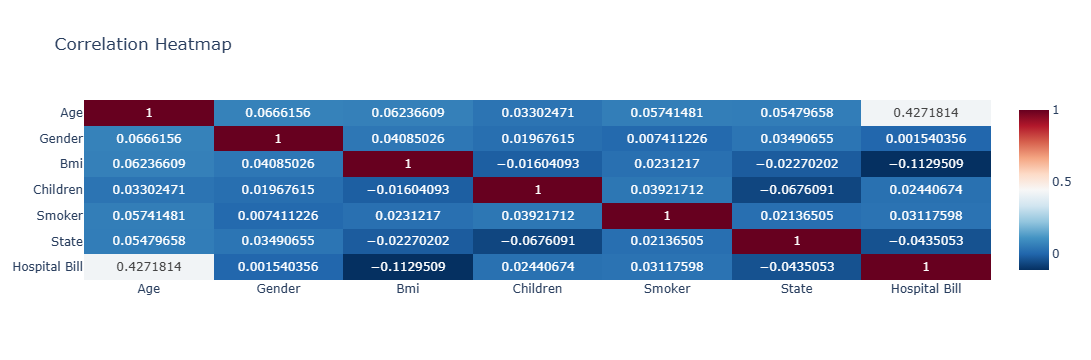

In [89]:
import plotly.express as px
from sklearn.preprocessing import LabelEncoder

corr_df = df.copy()

le = LabelEncoder()

for col in corr_df.select_dtypes(include="object"):
    corr_df[col] = le.fit_transform(corr_df[col])

corr = corr_df.corr()

fig9 = px.imshow(
    corr,
    text_auto=True,
    aspect="auto",
    color_continuous_scale="RdBu_r",
    title="Correlation Heatmap"
)

fig9.show()

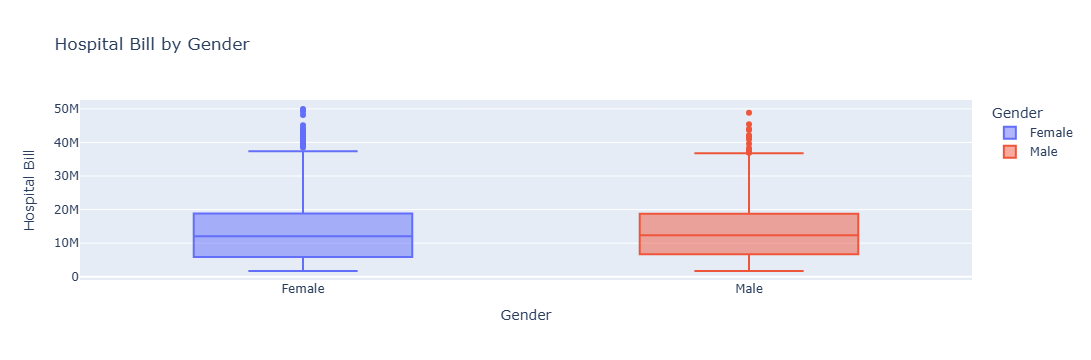

In [90]:
fig10 = px.box(
    df,
    x="Gender",
    y="Hospital Bill",
    color="Gender",
    title="Hospital Bill by Gender"
)

fig10.show()

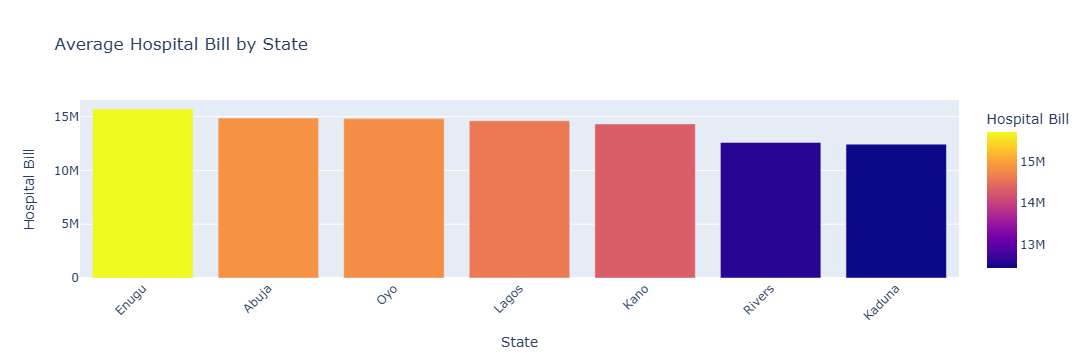

In [91]:
state_bill = (
    df.groupby("State", as_index=False)["Hospital Bill"]
      .mean()
      .sort_values("Hospital Bill", ascending=False)
)

fig11 = px.bar(
    state_bill,
    x="State",
    y="Hospital Bill",
    color="Hospital Bill",
    title="Average Hospital Bill by State"
)

fig11.update_layout(xaxis_tickangle=-45)

fig11.show()

In [92]:
df.to_csv("data/clean_nigeria_medical_insurance.csv", index=False)

# Exploratory Data Analysis (EDA) Report

## Introduction

The purpose of the Exploratory Data Analysis (EDA) was to understand the structure of the cleaned medical insurance dataset, identify patterns and relationships among variables, detect potential outliers, and gain insights that would support the development of an accurate medical cost prediction model.

## Univariate Analysis

The distributions of **Age**, **BMI**, and **Hospital Bill** were examined using histograms and boxplots. The age distribution showed that most patients belonged to the adult and middle-aged population. BMI values were concentrated within a moderate range, although a few extreme values were observed. Hospital bills displayed a right-skewed distribution, indicating that while most patients incurred relatively low to moderate healthcare costs, a small number experienced very high medical expenses.

The distributions of categorical variables such as **Gender**, **Smoker**, and **State** were also explored using bar charts to understand the composition of the dataset.

## Bivariate Analysis

Scatter plots and boxplots were used to investigate relationships between the predictor variables and hospital bills. A positive relationship was observed between **Age** and **Hospital Bill**, suggesting that older patients generally incur higher medical costs. Similarly, patients with higher **BMI** tended to have increased medical expenses.

The comparison of hospital bills across smoker categories revealed that smokers consistently had higher medical costs than non-smokers. Analysis by state showed noticeable regional differences in average hospital bills, indicating that geographical location may influence healthcare expenditure.

## Multivariate Analysis

A correlation heatmap and pairwise plots were used to examine relationships among multiple variables simultaneously. The analysis indicated that **Age**, **BMI**, and **Smoker** had stronger associations with hospital bills than other variables. Pairwise visualizations further confirmed positive relationships between these variables and medical costs while highlighting the presence of a few high-cost outliers.

## Key Findings

The EDA revealed several important insights:

* Hospital bills generally increase with age.
* Smokers incur substantially higher medical costs than non-smokers.
* Higher BMI is associated with increased healthcare expenses.
* Medical costs vary across different states, suggesting regional differences.
* Hospital bill values are positively skewed, with a small proportion of patients accounting for exceptionally high costs.

## Conclusion

The exploratory analysis provided valuable insights into the characteristics of the dataset and the factors influencing medical insurance costs. The findings suggest that demographic characteristics, lifestyle factors, and geographic location all contribute to variations in hospital bills. These insights informed feature selection and provided a strong foundation for building and evaluating predictive machine learning models in the subsequent phase of the project.
